<a href="https://colab.research.google.com/github/AidaSadeghi/Deep-Learning-with-pytorch/blob/main/Intermediate_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Advanced Architecture & Weight Dynamics
In deep networks, how you start is as important as how you finish. If weights are too small, signals vanish; if too large, they explode.

He (Kaiming) Initialization: Designed for layers followed by ReLU/ELU activations. It scales weights based on the number of input nodes to keep the variance of activations consistent.

Batch Normalization: This layer acts as a "check-and-balance" system. It normalizes the output of a previous layer by subtracting the batch mean and dividing by the batch standard deviation. This allows for higher learning rates and reduces sensitivity to initialization.

Vanishing Gradients: This occurs when gradients become so small during backpropagation that the early layers stop learning. Using ELU (Exponential Linear Unit) instead of ReLU helps because ELU can produce negative values, preventing neurons from "dying."

2. Optimization Strategy: Beyond SGD
Your notebooks transition from basic optimization to Adam. Understanding the difference is key for a portfolio:

Momentum: Like a ball rolling down a hill, momentum helps the optimizer accelerate through "flat" areas of the loss surface.

Adaptive Learning Rates (Adam): Adam calculates individual learning rates for different parameters. It keeps track of the "moving average" of gradients, making it robust for noisy data and complex architectures.

3. Transfer Learning & Model Surgery
When you don't have millions of data points, you use Fine-Tuning.

Freezing Layers: By setting requires_grad = False, you lock the "knowledge" of a pre-trained model (like one trained on millions of images).

The Head Swap: You typically remove the final layer (the "head") of a pre-trained model and replace it with a new layer specific to your data.


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. GENERATING SYNTHETIC DATA
# ==========================================
def get_dummy_data():
    # 500 samples, 20 features
    X = torch.randn(500, 20)
    y = torch.randint(0, 2, (500, 1)).float()
    return DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True)

# ==========================================
# 2. ADVANCED ARCHITECTURE
# ==========================================
class RobustNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: Linear -> Batch Norm -> ELU
        self.fc1 = nn.Linear(20, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.elu = nn.ELU()

        # Layer 2: Hidden
        self.fc2 = nn.Linear(64, 32)

        # Output Layer
        self.out = nn.Linear(32, 1)

        # Applying He Initialization manually
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='leaky_relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='leaky_relu')

    def forward(self, x):
        x = self.elu(self.bn1(self.fc1(x)))
        x = self.elu(self.fc2(x))
        return torch.sigmoid(self.out(x))

# ==========================================
# 3. TRAINING WITH GRADIENT INSPECTION
# ==========================================
model = RobustNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
train_loader = get_dummy_data()

print("--- Training Progress ---")
for epoch in range(3):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Portfolio Tip: Show you understand gradients by monitoring them
        if batch_idx == 0:
            grad_norm = model.fc1.weight.grad.norm().item()
            print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Grad Norm: {grad_norm:.6f}")

        optimizer.step()

# ==========================================
# 4. MODEL SURGERY (Fine-Tuning Example)
# ==========================================
print("\n--- Performing Model Surgery ---")
# Freeze the first layer to preserve 'feature detection'
for param in model.fc1.parameters():
    param.requires_grad = False

# Replace the output layer for a new task (e.g., 5-class classification)
model.out = nn.Linear(32, 5)
print("Updated Model Head for 5-class classification:")
print(model.out)



--- Training Progress ---
Epoch 1 | Loss: 0.8308 | Grad Norm: 0.213330
Epoch 2 | Loss: 0.6892 | Grad Norm: 0.135740
Epoch 3 | Loss: 0.7098 | Grad Norm: 0.126649

--- Performing Model Surgery ---
Updated Model Head for 5-class classification:
Linear(in_features=32, out_features=5, bias=True)


In [32]:
model

RobustNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (elu): ELU(alpha=1.0)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features)
            # Ensure predictions are binary (0 or 1)
            preds = (outputs > 0.5).float()

            # Move to CPU and convert to numpy
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # CRITICAL FIX: Flatten the lists of arrays into a single 1D array
    # This converts [[0], [1]] into [0, 1]
    y_pred = np.concatenate(all_preds).ravel()
    y_true = np.concatenate(all_labels).ravel()

    # Ensure they are integers for the report
    y_pred = y_pred.astype(int)
    y_true = y_true.astype(int)

    print("--- Detailed Performance Metrics ---")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    cm

--- Detailed Performance Metrics ---
              precision    recall  f1-score   support

     Class 0       0.42      0.48      0.45       234
     Class 1       0.48      0.42      0.44       266

    accuracy                           0.45       500
   macro avg       0.45      0.45      0.45       500
weighted avg       0.45      0.45      0.45       500



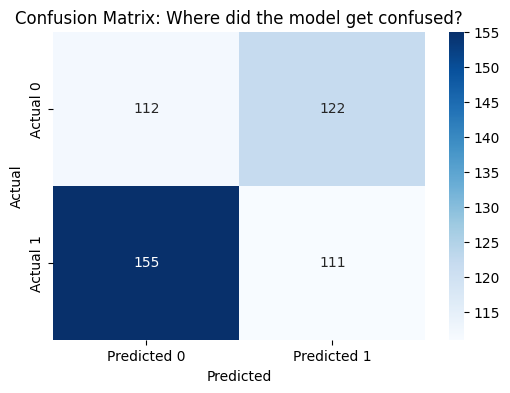

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            outputs = model(features)
            preds = (outputs > 0.5).float()

            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    # 1. Classification Report (Precision, Recall, F1)
    print("--- Detailed Performance Metrics ---")
    print(classification_report(all_labels, all_preds, target_names=['Class 0', 'Class 1']))

    # 2. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Where did the model get confused?')
    plt.show()


# If you defined your model like this:
model = RobustNet()

# Call the evaluation like this:
evaluate_model(model, train_loader)

--- Starting Training ---
Epoch 1 done.
Epoch 2 done.
Epoch 3 done.
Epoch 4 done.
Epoch 5 done.
Epoch 6 done.
Epoch 7 done.
Epoch 8 done.
Epoch 9 done.
Epoch 10 done.


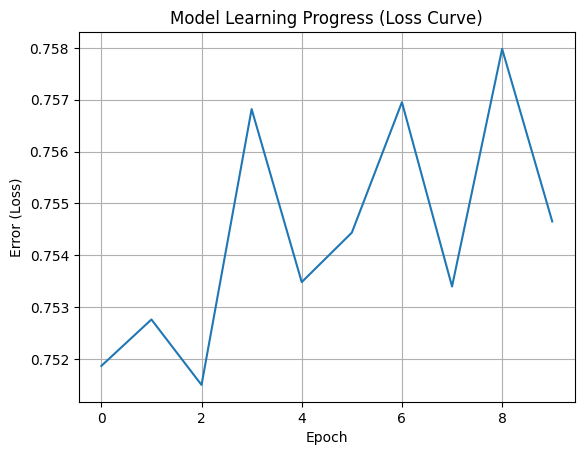

In [48]:
import matplotlib.pyplot as plt

# 1. Initialize an empty list to store history
train_losses = []

print("--- Starting Training ---")
for epoch in range(10):  # Run for 10 epochs to see a good curve
    model.train()
    running_loss = 0.0

    for features, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels.view(-1, 1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # 2. Save the average loss for this epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} done.")

# 3. NOW call the function to see the result
plot_learning_curve(train_losses)

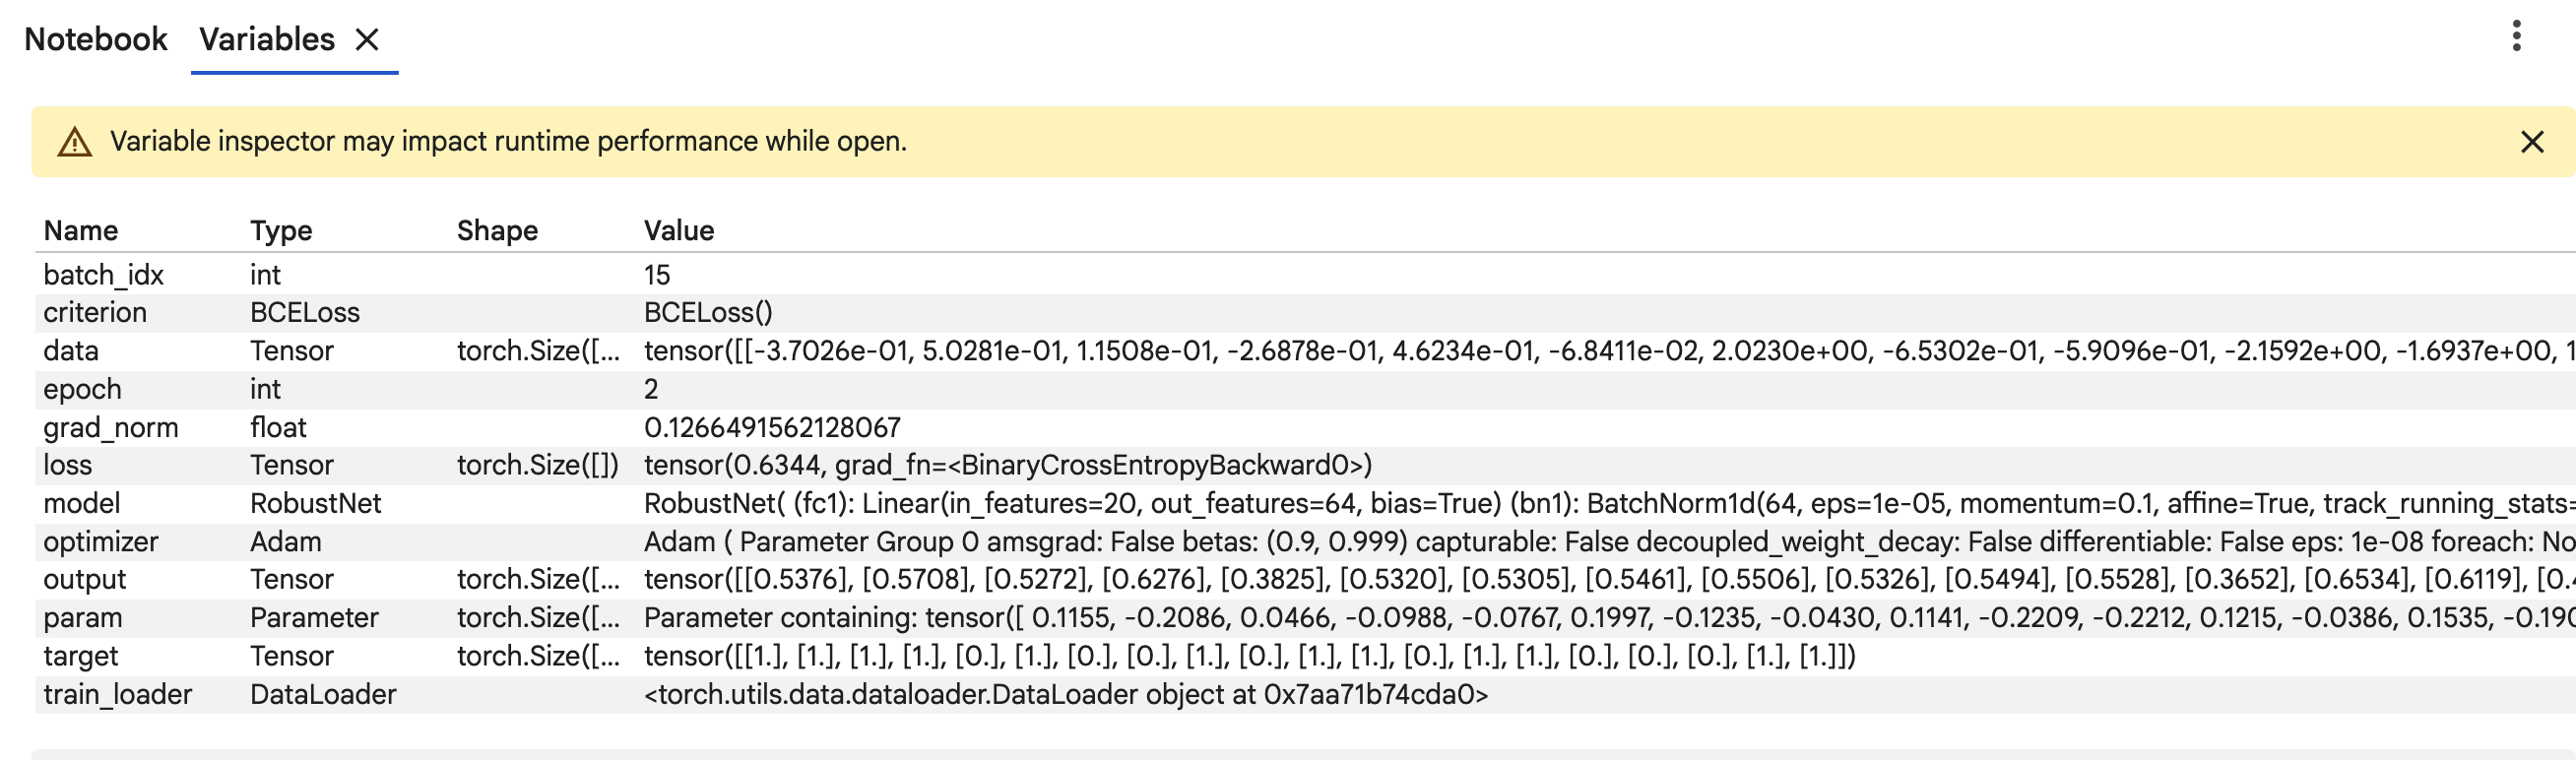

In [42]:
output

tensor([[0.5376],
        [0.5708],
        [0.5272],
        [0.6276],
        [0.3825],
        [0.5320],
        [0.5305],
        [0.5461],
        [0.5506],
        [0.5326],
        [0.5494],
        [0.5528],
        [0.3652],
        [0.6534],
        [0.6119],
        [0.4895],
        [0.5193],
        [0.4989],
        [0.3325],
        [0.5362]], grad_fn=<SigmoidBackward0>)

In [43]:
loss

tensor(0.6344, grad_fn=<BinaryCrossEntropyBackward0>)

**Accuracy**:  Overall Correctness"High-level snapshot of performance.

**Precision**:  Reliability of 'Yes'"How much we can trust the model when it flags something.

**Recall**:  Capture Rate"How many actual cases did we catch versus how many we missed?

**Loss**:  The Margin of Error"Shows how 'confident' the model's mistakes are.

--- Training Started ---
Epoch 1/10 | Average Loss: 0.7072
Epoch 2/10 | Average Loss: 0.6892
Epoch 3/10 | Average Loss: 0.6820
Epoch 4/10 | Average Loss: 0.6781
Epoch 5/10 | Average Loss: 0.6761
Epoch 6/10 | Average Loss: 0.6726
Epoch 7/10 | Average Loss: 0.6694
Epoch 8/10 | Average Loss: 0.6590
Epoch 9/10 | Average Loss: 0.6626
Epoch 10/10 | Average Loss: 0.6665


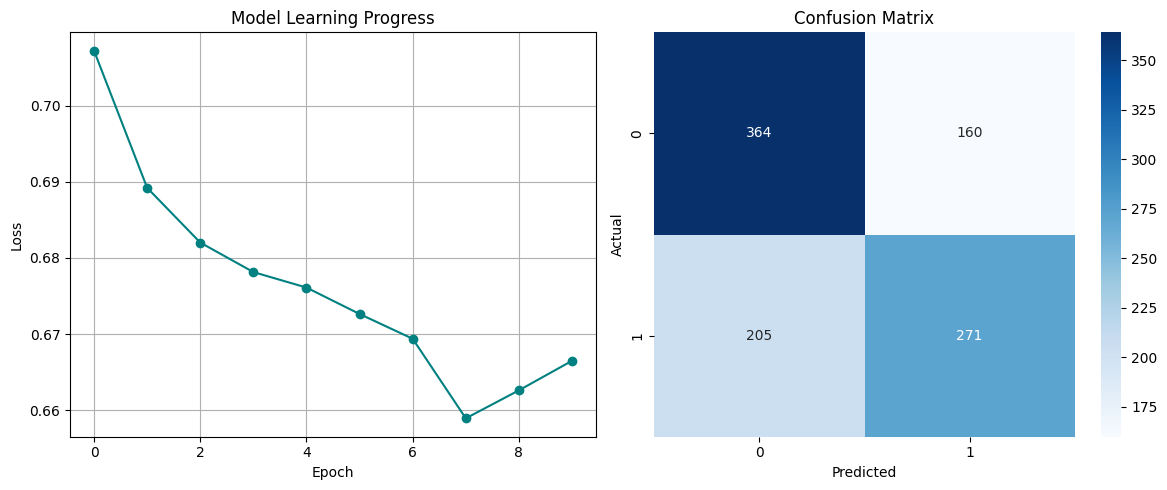


--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.64      0.69      0.67       524
           1       0.63      0.57      0.60       476

    accuracy                           0.64      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.63      0.64      0.63      1000



In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. SETUP & DUMMY DATA
# ==========================================
# Creating 1000 samples with 10 features for a binary classification task
X_dummy = torch.randn(1000, 10)
y_dummy = torch.randint(0, 2, (1000, 1)).float()

train_loader = DataLoader(TensorDataset(X_dummy, y_dummy), batch_size=32, shuffle=True)

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class PortfolioNet(nn.Module):
    def __init__(self):
        super().__init__()
        # As seen in your image: y = xW^T + b
        self.hidden = nn.Linear(10, 16)
        self.bn = nn.BatchNorm1d(16)
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn(self.hidden(x)))
        return self.sigmoid(self.output(x))

model = PortfolioNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

# ==========================================
# 3. TRAINING LOOP (With Loss Tracking)
# ==========================================
train_losses = []

print("--- Training Started ---")
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/10 | Average Loss: {avg_loss:.4f}")

# ==========================================
# 4. VISUALIZATION & EVALUATION
# ==========================================
def run_full_evaluation(model, loader, losses):
    # Plot 1: Learning Curve
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(losses, marker='o', color='teal')
    plt.title('Model Learning Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    # Predictions for Confusion Matrix
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds = (model(x) > 0.5).float()
            all_preds.append(preds.numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).ravel().astype(int)
    y_pred = np.concatenate(all_preds).ravel().astype(int)

    # Plot 2: Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print("\n--- Final Classification Report ---")
    print(classification_report(y_true, y_pred))

# Execute Evaluation
run_full_evaluation(model, train_loader, train_losses)